In [42]:
!pip3 install -Uq numpy scipy einsteinpy matplotlib

In [43]:
import numpy as np

In [44]:
def ed_espacio_tiempo(tau, Ys, alpha):
    # Ys contiene todas las variables del problema
    # T, x, y, z, Ut, Ux, Uy, Uz
    T, x, y, z, Ut, Ux, Uy, Uz = Ys

    # Ecuaciones de movimiento
    dT_dtau = Ut
    dx_dtau = Ux
    dy_dtau = Uy
    dz_dtau = Uz

    # ¿Cuánto valen las componentes de A?
    # Aceleración propia:
    Apropia = np.array([0, alpha, 0, 0])

    # La aceleración en el sistema de coordenadas del observador
    gamma = Ut
    beta = Ux / gamma
    
    Lambda = np.array([
        [gamma, gamma*beta, 0, 0],
        [gamma*beta, gamma, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])


    Atierra = Lambda @ Apropia


    dUt_dtau = Atierra[0]
    dUx_dtau = Atierra[1]
    dUy_dtau = Atierra[2]
    dUz_dtau = Atierra[3]

    return dT_dtau, dx_dtau, dy_dtau, dz_dtau, dUt_dtau, dUx_dtau, dUy_dtau, dUz_dtau

Condiciones iniciales

Unidades relativistas

In [45]:
c_SI = 299792458 # m/s
c = 1 #velocidad de la luz en unidades relativistas
UT = 365.25 * 86400 #segundos en un año
# c = 1, c = UL / UT
UL = c_SI * UT
UV = UL / UT
UA = UL / (UT**2)

Condiciones iniciales expresadas en coordenadas espaciales y temporales

In [46]:
t = 0
x = 0
y = 0
z = 0

vx = 0
vy = 0
vz = 0

Condiciones iniciales expresadas como cuadrivectores

In [54]:
T = c*t
# x,y,z: son las mismas
gamma = 1 / np.sqrt(1 - (vx**2 + vy**2 + vz**2) / c**2)
Ut = gamma * c
Ux = gamma * vx
Uy = gamma * vy
Uz = gamma * vz

Y0 = np.array([T, x, y, z, Ut, Ux, Uy, Uz])
Y0

array([0., 0., 0., 0., 1., 0., 0., 0.])

In [48]:
from scipy.integrate import solve_ivp

In [67]:
alpha = 9.8 / UA
taus = np.linspace(0, 2.2, 100)
solucion = solve_ivp(ed_espacio_tiempo, (taus[0], taus[-1]), Y0, args=(alpha,), t_eval=taus)

In [68]:
solucion

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  2.222e-02 ...  2.178e+00  2.200e+00]
        y: [[ 0.000e+00  2.222e-02 ...  4.532e+00  4.639e+00]
            [ 0.000e+00  2.547e-04 ...  3.665e+00  3.770e+00]
            ...
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 38
     njev: 0
      nlu: 0

Extracción de la solución

In [69]:
taus = solucion.t
Ts = solucion.y[0]
xs = solucion.y[1]
ys = solucion.y[2]
zs = solucion.y[3]

Uts = solucion.y[4]
Uxs = solucion.y[5]
Uys = solucion.y[6]
Uzs = solucion.y[7]

Convertir las medidas espacio-temporales en medidas espaciales y temporales

In [70]:
ts = Ts / c
# x,y,z: son los mismos

# Sabemos que U: (gamma_v*c, gamma_v*v)
gammas = Uts / c
vxs = Uxs / gammas
vys = Uys / gammas
vzs = Uzs / gammas

Graficar

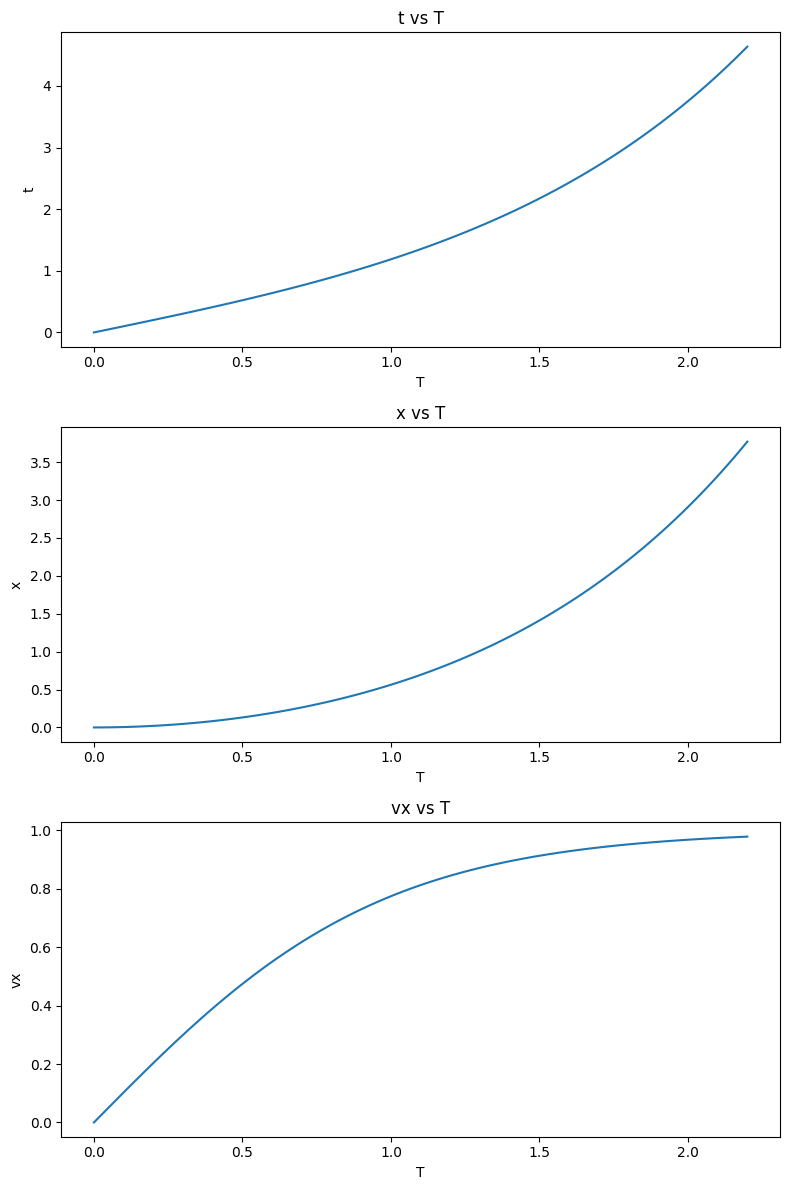

In [71]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(8, 12))

# eje independiente: T (Ts)
axs[0].plot(taus, ts)
axs[0].set_xlabel('T')
axs[0].set_ylabel('t')
axs[0].set_title('t vs T')

axs[1].plot(taus, xs)
axs[1].set_xlabel('T')
axs[1].set_ylabel('x')
axs[1].set_title('x vs T')

axs[2].plot(taus, vxs)
axs[2].set_xlabel('T')
axs[2].set_ylabel('vx')
axs[2].set_title('vx vs T')

plt.tight_layout()